<a href="https://colab.research.google.com/github/amarshssingh0011/PROJECT-2/blob/main/2_outliers_z_score_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align='center' style='color:blue'>Exercise: Outlier removal using standard deviation and z score<h2>

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bhp.csv to bhp.csv


In [3]:
df = pd.read_csv("bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


We will quickly examine price_per_sqft column to check min,max,mean and percentile values

In [4]:
df.price_per_sqft.describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


Above, you can see max is 12000000, which is too much price for price per sqft. Looks like this dataset has some very bad outliers so we will first remove those with percentile and then use z score

Also **plot histogram** to see how is the data distribution

<Axes: >

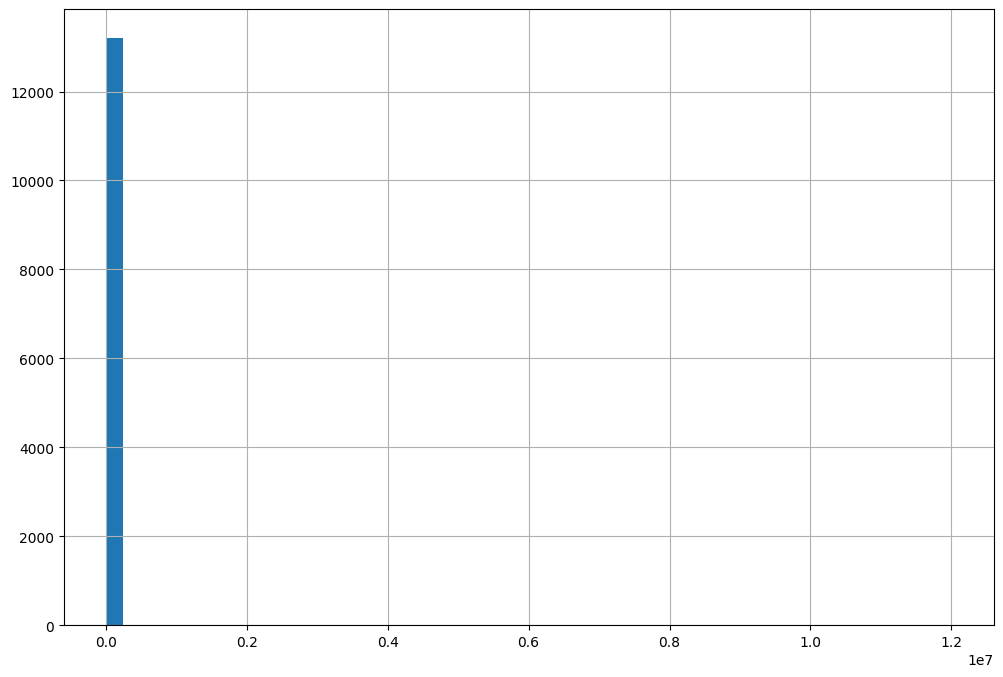

In [10]:
df['price_per_sqft'].hist(bins=50)

Above chart confirms our understanding that this dataset has some bad outliers. Because we see only one bar with more than 12000 data points but on the right hand side there are data points that have higher value for price per sqft but count of these data points is very tiny compared to 12000 hence we can hardly see any bar

Using **log scale** can make visualization little better

In [11]:
print(df['price_per_sqft'].quantile(0.999))

50959.36200000098


You see atleast few bars on right hand side of our highest building at least :)

<h3 style='color:purple'>(1) Treat outliers using percentile first</h3>

In [12]:
filtered_df = df[df['price_per_sqft'] < 31250.0]

<Axes: >

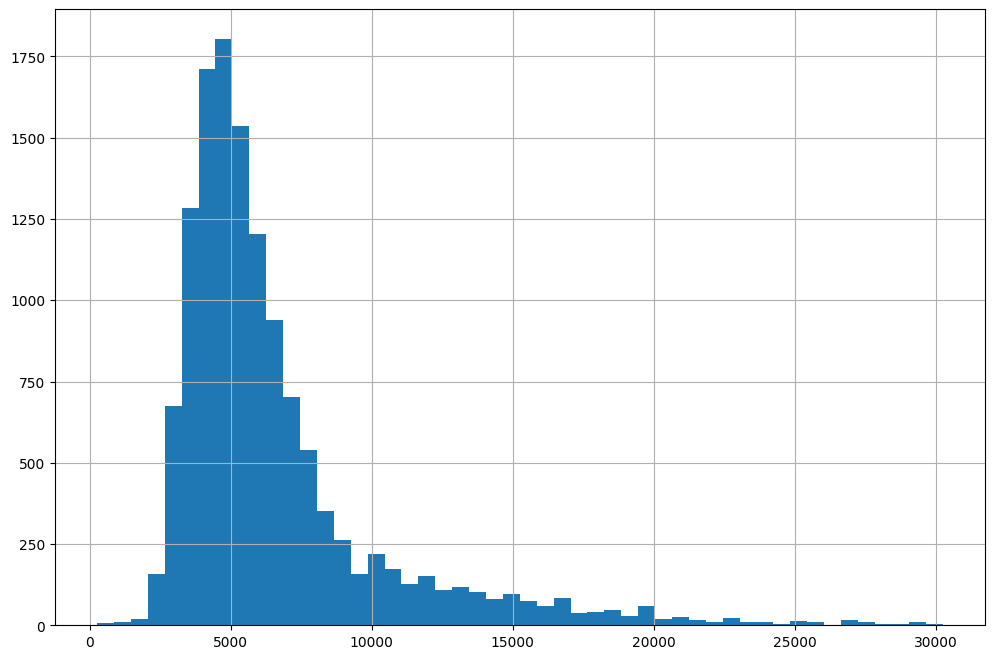

In [13]:
filtered_df['price_per_sqft'].hist(bins=50)

<Axes: >

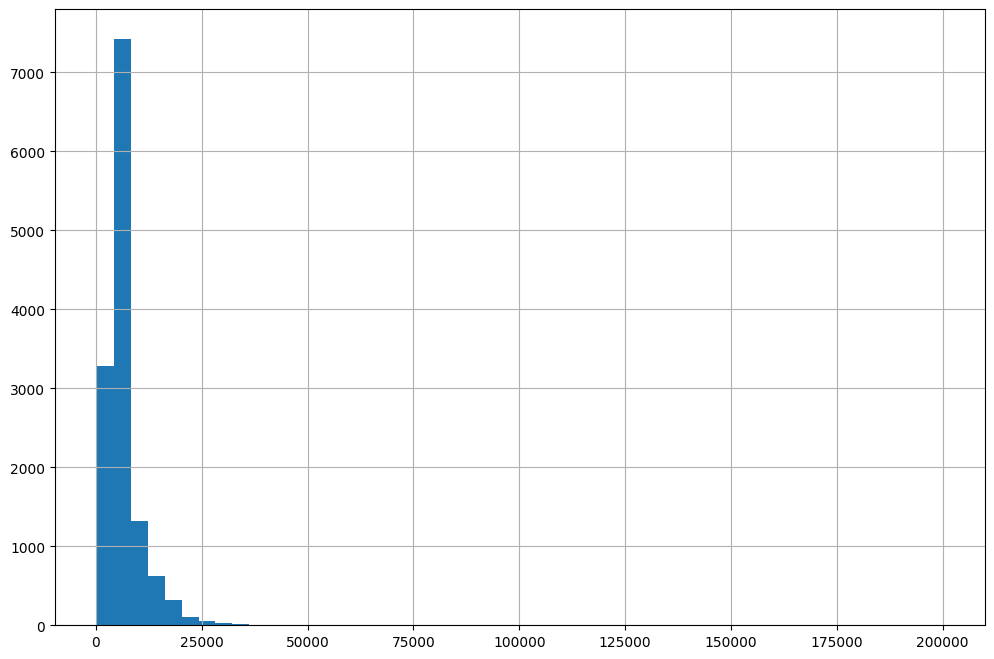

In [14]:
upper_limit = df['price_per_sqft'].mean() + 3 * df['price_per_sqft'].std()
lower_limit = df['price_per_sqft'].mean() - 3 * df['price_per_sqft'].std()

df_no_outliers = df[(df['price_per_sqft'] < upper_limit) & (df['price_per_sqft'] > lower_limit)]
df_no_outliers['price_per_sqft'].hist(bins=50)

Above shows properties that has price_per_sqft value such as 500 rs which is very very low for the city of banglore. You would be very lucky if you can find such as property :)
Also we have properties that has price per sqft value such as 12000000 which is way too high. It seems almost impossible and even if it is legitimate it can help data analysis process if we remove such a data point

In [15]:
import pandas as pd

In [16]:
df.shape

(13200, 7)

In [17]:
lower_limit = df['price_per_sqft'].quantile(0.001)
upper_limit = df['price_per_sqft'].quantile(0.999)
df = df[(df['price_per_sqft'] > lower_limit) & (df['price_per_sqft'] < upper_limit)]

**We removed total 28 outliers**

<h3 style='color:purple'>(2) Now remove outliers using 4 standard deviation</h3>

In [18]:
df.shape

(13172, 7)

In [20]:
max_limit = df['price_per_sqft'].mean() + 4 * df['price_per_sqft'].std()
min_limit = df['price_per_sqft'].mean() - 4 * df['price_per_sqft'].std()

df_no_outlier_z = df[(df['price_per_sqft'] > min_limit) & (df['price_per_sqft'] < max_limit)]


df_no_outlier_z.shape

(13012, 7)

In [21]:
upper_limit = df['price_per_sqft'].mean() + 4 * df['price_per_sqft'].std()
lower_limit = df['price_per_sqft'].mean() - 4 * df['price_per_sqft'].std()


df3 = df[(df['price_per_sqft'] > lower_limit) & (df['price_per_sqft'] < upper_limit)]

df3.shape

(13012, 7)

<Axes: >

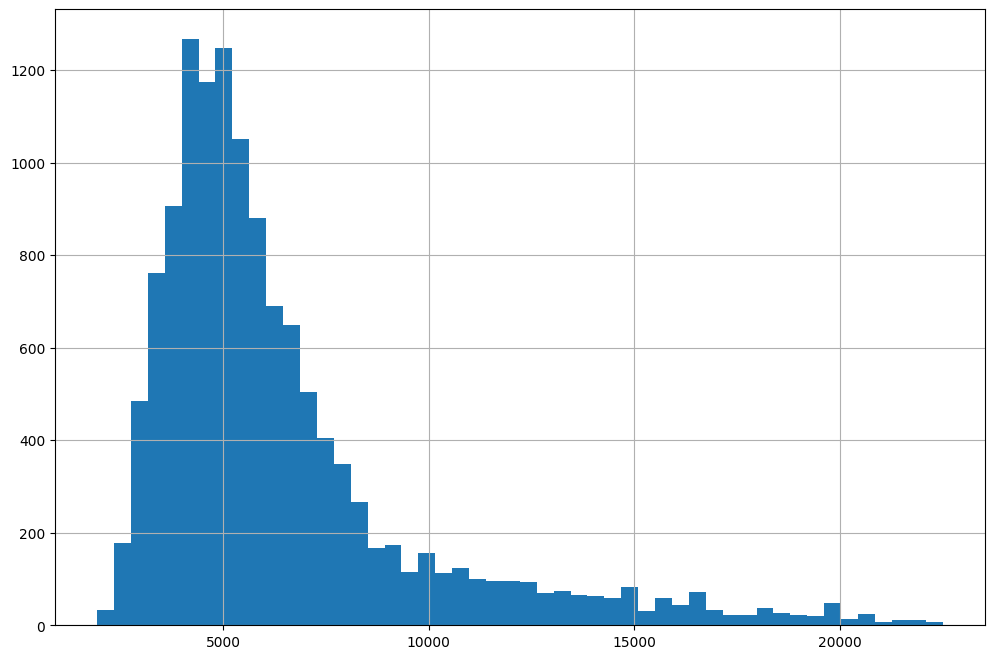

In [22]:
df3['price_per_sqft'].hist(bins=50)

In this step we removed total 125 outliers

In [23]:
df['zscore'] = (df['price_per_sqft'] - df['price_per_sqft'].mean()) / df['price_per_sqft'].std()


df4 = df[(df['zscore'] > -4) & (df['zscore'] < 4)]


df4.shape

(13012, 8)

In [24]:
df['zscore'] = (df['price_per_sqft'] - df['price_per_sqft'].mean()) / df['price_per_sqft'].std()


df4 = df[(df['zscore'] > -4) & (df['zscore'] < 4)]


df4.shape

(13012, 8)

<h3 style='color:purple'>(3) Now remove outliers using z score. Use z score of 4 as your thresold</h3>

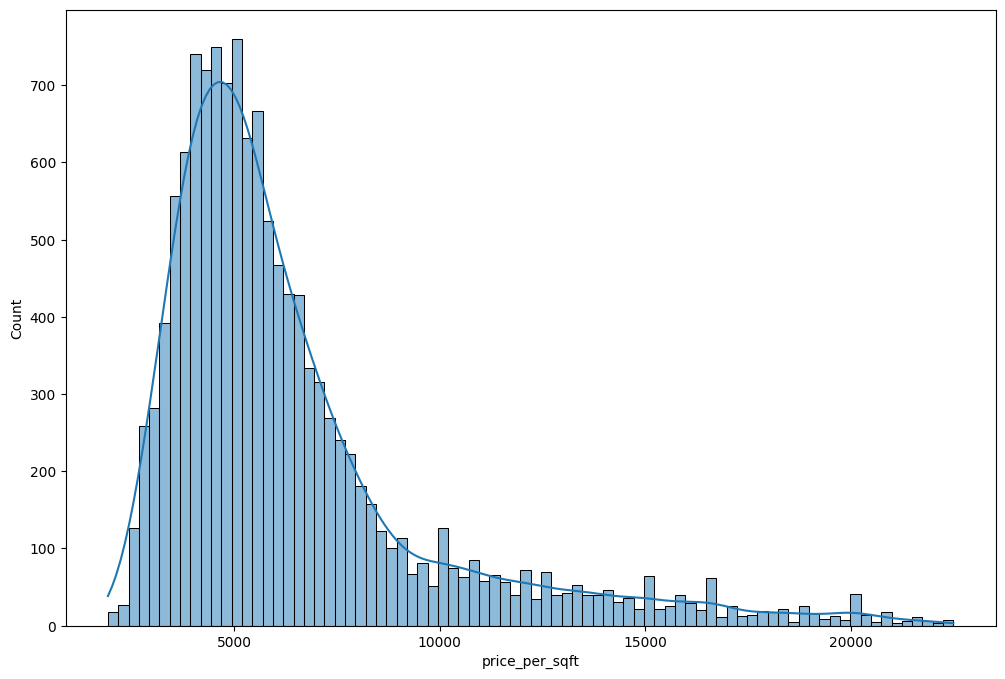

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df4['price_per_sqft'], kde=True)
plt.show()

In [26]:
df.loc[:, 'zscore'] = (df['price_per_sqft'] - df['price_per_sqft'].mean()) / df['price_per_sqft'].std()

df_no_outliers = df[(df['zscore'] > -4) & (df['zscore'] < 4)]

df_no_outliers.shape

(13012, 8)

<Axes: >

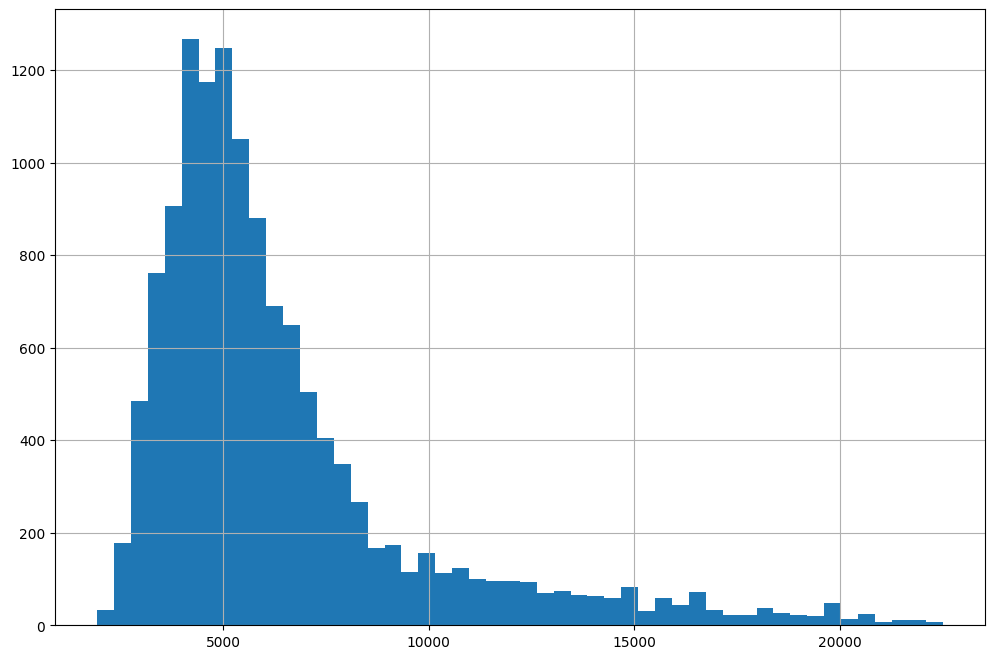

In [27]:
df_no_outliers['price_per_sqft'].hist(bins=50)

125

In this step also we removed 125 outliers. The result would be exactly same as 4 standard deviation